## MNIST - alcene.ai

This is a MNIST model developed and trained by **alcene.ai** as early example of learning ML.

## Imports
All the libs we need to run this project.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch.nn.functional as F
import numpy as np

## Load & Transform Data to Tensor
Load the processed MNIST training data from `./data/processed` then transform it to Tensor so that PyTorch can manipulate it.

In [2]:
data = np.load("../data/processed/mnist_processed.npz")
x_train = torch.tensor(data["x_train"], dtype=torch.float32)
y_train = torch.tensor(data["y_train"], dtype=torch.long)
x_test = torch.tensor(data["x_test"], dtype=torch.float32)
y_test = torch.tensor(data["y_test"], dtype=torch.long)

    
print(data)

print("x_train", x_train.shape, x_train.dtype, x_train.min().item(), x_train.max().item())
print("y_train", y_train.shape, y_train.dtype)
print("x_test ", x_test.shape, "y_test", y_test.shape)

NpzFile '../data/processed/mnist_processed.npz' with keys: x_train, y_train, x_test, y_test
x_train torch.Size([60000, 28, 28]) torch.float32 0.0 1.0
y_train torch.Size([60000]) torch.int64
x_test  torch.Size([10000, 28, 28]) y_test torch.Size([10000])


# Verify the Training Sets Are Corrects
If the image and label are mismatched since the beginning, this will be a big issues henceforth we must confirm that label and images are corrects.

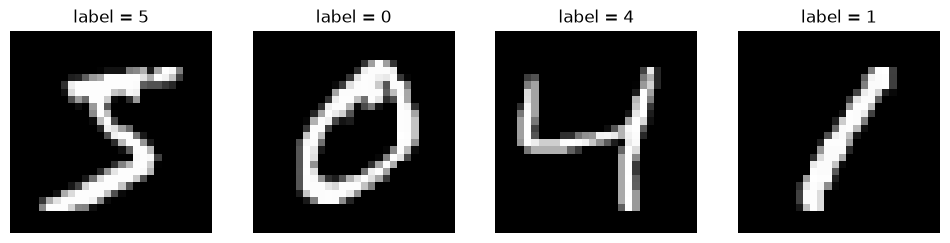

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, i in zip(axes, [0, 1, 2, 3]):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"label = {y_train[i].item()}")
    ax.axis("off")
plt.show()

## Package to Unified Dataset
Currently `x_train` and `y_train` are two separate tensors. The model needs a single object that hands back `(image, label)` pairs.

In [4]:
dataset = TensorDataset(x_train, y_train) # We don't use zip because PyTorch need Dataset datatype.

# Try dataset from index 0
img, label = dataset[0]
print(img.shape, label)

torch.Size([28, 28]) tensor(5)


## Spliting Dataset
We don't want the model to "memorize" the data, we want it to "generalize" it, thus we don't train it overmuch to prevent overfitting. That's why we split the dataset to smaller portion and use part of it as tests mid training.

In [5]:
# Stands for: training, validation.
train_ds, val_ds = random_split(dataset, [50_000, 10_000])

print(len(train_ds), len(val_ds))

50000 10000


## Data Batching and Shuffling
Loading 50k images at once will put a heavy toll on computing inference, thus we split it into smaller batches. At the same time when creating the batches, we also shuffle the data so it's more random henceforth making the model more generalizing rather than memorizing pattern order.

In [6]:
batch_size = 64

train_loader = DataLoader(train_ds, batch_size, shuffle=True)

# Validation dataset aren't shuffled to easily measure and compare metrics
# across different model final weights.
val_loader = DataLoader(val_ds, batch_size, shuffle=False)

## Model
We must flatten the image from 28x28 pixels into 1D (1 x 784) matrices. After that we maps to hidden layer neurons down to 128, at this stage we use `ReLU` to convert negative values into 0.

In [7]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 10)
    # We don't apply ReLU to visible layer because we need to use
    # the negatives value to calculate how far the prediction from
    # the model from the actual label.
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=128, out_features=10, bias=True)
)


## Loss and Correction Function
We have previously modeled the model itself, now we need to have a function that train and correcting how far the answer deviate from the labels. This function is the one whose responsible to compares model output to the answer.

In [8]:
# This one to calculate how off is the guess
loss_fn = nn.CrossEntropyLoss()

# This one to optimize the model
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

## Training the Model
To train the model, we have to run it for a predefined many times (epochs) against the datasets we has.

In [9]:
num_train_epochs = 8

for epoch in range(num_train_epochs):
    # Training phase
    running_loss = 0.0
    
    for batch in train_loader:
        # Batch contains two sets, images and labels so unpack
        images, labels = batch

        # Ask the model to guess
        output = model(images)

        # Calculate how far the guess is
        loss = loss_fn(output, labels)

        # Correction the model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print average loss per batch for this epoch
    print(
        f"Epoch {epoch+1}/{num_train_epochs} - Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/8 - Loss: 0.3472
Epoch 2/8 - Loss: 0.1494
Epoch 3/8 - Loss: 0.1107
Epoch 4/8 - Loss: 0.0913
Epoch 5/8 - Loss: 0.0771
Epoch 6/8 - Loss: 0.0693
Epoch 7/8 - Loss: 0.0613
Epoch 8/8 - Loss: 0.0547


## Evaluation
Do evaluation on the trained model against the benchmark datasets.

In [10]:
model.eval()

# Import the tests datasets
test_ds = TensorDataset(x_test, y_test)

test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

total, correct = 0, 0

with torch.no_grad():
    # We use the 10k splitted from earlier random split
    for batch in val_loader:
        # Evaluation sets also contains the same images and labels
        images, labels = batch

        output = model(images)

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)
        
    # This is are the true test datasets from the MNIST Dataset
    for batch in test_loader:
            # Evaluation sets also contains the same images and labels
            images, labels = batch
    
            output = model(images)
    
            predictions = output.argmax(dim=1)
    
            correct += (predictions == labels).sum().item()
    
            total += labels.size(0)

accuracy = (correct / total) * 100
print(f"Accuracy: {accuracy:.2f}% out of {total} samples.")

Accuracy: 98.02% out of 20000 samples.


Visually evaluate it:

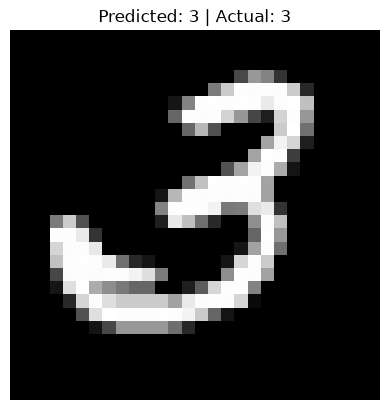

In [70]:
# Grab single batch from validation set
import random as r
a = r.randint(0, 63)

images, labels = next(iter(val_loader))

# Run prediction on first image
model.eval()
with torch.no_grad():
    output = model(images[a].unsqueeze(0))
    predicted = output.argmax(dim=1).item()

# Plot image and display prediction
plt.imshow(images[a].squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted} | Actual: {labels[a].item()}")
plt.axis('off')
plt.show()

## Save the Weight
After training, we could save the weight into `models`.

In [71]:
torch.save(model.state_dict(), '../models/mnist.pth')